# GSA - 300 Aquisição de Dados Digitais e Inteligência Artificial em Geociências (2025)

## Introdução

Como um dos métodos mais importantes para o desenveolvimento do conhecimento humano, o mapeamento geológico é de fundamental importância a execução de uma enorme varidade de atividades humanas desde qualquer uso e ocupação do solo, como na propecção de minerais essenciais para a manutenção e avanço da sociedade. O Brasil possui um território continental e grande parte desta área possui uma densa cobertura vegetal que dificulta dsecrição de rochas aflorantes tanto tanto in situ qunato por métodos de aquisição de dados remota, com isso a utilização técnicas de aprendizagem de máquina para segmentar e, ou, classificar dados contínuos e regularmente espaçados, segundo Ting Pan;

 que atende aos multiplos critérios para a execução deste método é a área coberta pela folha cartográfica de código SB.21-Z-A-II-1-NE

fid: 4198
id_folha: SB21_ZA_II1_NE
EPSG: 32721

SB21_ZA_II

"A principal inovação nesse tipo de produto cartográfico com relação à categoria 9 é a introdução no mapeamento geológico da tecnologia SIG ou Sistema de Informações Geográficas, de forma sistemática, cuja estruturação está respaldada em"

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import pyproj
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
pg_user = "postgres"
pg_pass = "postgres"
pg_host = "localhost"
pg_port = "5432"
pg_db   = "geologia"

engine = create_engine(
    f"postgresql+psycopg2://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}"
)

gamma_cols = [
    "ctcor_np",
    "kperc_np",
    "eu_np",
    "eth_np",
    'thk_razao','uth_razao','uk_razao',
]

loc_cols = [
    'x', 'y', 'mdt',
    'lat', 'lon', 'temp', 'sample_id', 'line_id','survey_code',
    'folha_id', 'folha_codigo', 'folha_escala', 'folha_epsg',
]

lito_cols = [
    'lito100k_id_unidade',
    'lito100k_sigla',
    'lito100k_nome',
    'lito100k_legenda',
]


cols = gamma_cols+loc_cols+lito_cols

sql = f"""
SELECT {", ".join(cols)}
FROM geof.v_gamma_1082_sb21_za_ii
"""


In [3]:
df_gamma = pd.read_sql_query(sql, engine)

In [10]:
df_gamma[gamma_cols+['mdt']].describe().T

,count,mean,std,min,25%,50%,75%,max
ctcor_np,79993.0,1026.552213,439.628351,96.436,723.664,959.102,1220.184,4604.002
kperc_np,79993.0,0.393091,0.246819,0.000,0.227,0.352,0.509,2.426
eu_np,79993.0,1.199330,0.873663,0.000,0.546,1.072,1.666,8.494
eth_np,79993.0,15.323701,6.607747,1.848,10.628,13.866,18.776,66.697
thk_razao,79993.0,58.711349,88.039920,0.000,24.436,37.103,60.541,2864.625
uth_razao,79993.0,0.080808,0.051321,0.000,0.046,0.075,0.109,0.938
uk_razao,79993.0,4.506020,7.388891,0.000,1.407,2.823,5.018,226.872
mdt,79993.0,222.651261,57.632930,107.100,179.350,215.030,255.690,425.320


In [11]:
df_gamma.describe().T

,count,mean,std,min,25%,50%,75%,max
ctcor_np,79993.0,1.026552e+03,439.628351,9.643600e+01,7.236640e+02,9.591020e+02,1.220184e+03,4.604002e+03
kperc_np,79993.0,3.930912e-01,0.246819,0.000000e+00,2.270000e-01,3.520000e-01,5.090000e-01,2.426000e+00
eu_np,79993.0,1.199330e+00,0.873663,0.000000e+00,5.460000e-01,1.072000e+00,1.666000e+00,8.494000e+00
eth_np,79993.0,1.532370e+01,6.607747,1.848000e+00,1.062800e+01,1.386600e+01,1.877600e+01,6.669700e+01
thk_razao,79993.0,5.871135e+01,88.039920,0.000000e+00,2.443600e+01,3.710300e+01,6.054100e+01,2.864625e+03
uth_razao,79993.0,8.080796e-02,0.051321,0.000000e+00,4.600000e-02,7.500000e-02,1.090000e-01,9.380000e-01
uk_razao,79993.0,4.506020e+00,7.388891,0.000000e+00,1.407000e+00,2.823000e+00,5.018000e+00,2.268720e+02
x,79993.0,5.830385e+05,15914.463102,5.553930e+05,5.694260e+05,5.834230e+05,5.964460e+05,6.104490e+05
y,79993.0,9.309068e+06,15959.538903,9.281427e+06,9.295252e+06,9.309051e+06,9.322878e+06,9.336765e+06
mdt,79993.0,2.226513e+02,57.632930,1.071000e+02,1.793500e+02,2.150300e+02,2.556900e+02,4.253200e+02


In [7]:
df_folha_lito = df_gamma
df_folha_lito.columns

Index(['ctcor_np', 'kperc_np', 'eu_np', 'eth_np', 'thk_razao', 'uth_razao',
       'uk_razao', 'x', 'y', 'mdt', 'lat', 'lon', 'temp', 'sample_id',
       'line_id', 'survey_code', 'folha_id', 'folha_codigo', 'folha_escala',
       'folha_epsg', 'lito100k_id_unidade', 'lito100k_sigla', 'lito100k_nome',
       'lito100k_legenda'],
      dtype='object')

In [13]:
cols_geof = [ "mdt", "ctcor_np", "kperc_np", "eu_np", "eth_np", "thk_razao", "uk_razao", "uth_razao"]
print(f' N. Amostras: {df_folha_lito.shape[0]}')
print(f' N. Colunas: {df_folha_lito.shape[1]}')
print('')
print('Valores nulos: ')
print(f'{df_folha_lito[cols_geof].isna().sum()}')

lit_nome = df_folha_lito.lito100k_nome.unique()
lit_unidade_sigla = df_folha_lito.lito100k_sigla.unique()
lit_legenda = df_folha_lito.lito100k_legenda.unique()
print('')

print(lit_nome)
print(lit_unidade_sigla)
print(lit_legenda)
print(cols_geof)

 N. Amostras: 79993
 N. Colunas: 24

Valores nulos: 
mdt          0
ctcor_np     0
kperc_np     0
eu_np        0
eth_np       0
thk_razao    0
uk_razao     0
uth_razao    0
dtype: int64

['Complexo Cuiú-Cuiú' 'Membro Lora' 'Suíte Maloquinha'
 'Depósitos aluvionares' 'Membro Manual' 'Suíte Creporizão'
 'Formação Tocantinzinho' 'Corpo Gabro São Domingos'
 'Coberturas Lateríticas Imaturas' 'Fácies Parauari, granodiorítica'
 'Membro Riozinho das Arraias' 'Suíte Ingarana']
['PP3cc' 'PP3_alfa_cl' 'PP3_gamma_ml' 'Q2a' 'PP3_alfa_cm' 'PP3_gamma_cz'
 'PP3_alfa_tz' 'PP3_delta_ins' 'N1Q1li' 'PP3_gamma_pgd' 'PP3_alfa_vra'
 'PP3_delta_in']
['Gnaisse tonalítico a monzogranítico com migmatito e anfibolito subordinados e raros metagranitóides fracamente gnaissificados. Monzogranito, quartzo monzonito e granodiorito, com biotita, anfibólio e titanita, subordinados sienogranito, quartzo sieni'
 'Andesitos, dacitos e riodacitos porfiríticos, ignimbritos dacíticos e riolíticos. Ocorrem como derrames de lav

In [14]:
df_folha_lito[cols_geof].describe(percentiles=[0.005,0.01,0.1,0.25,0.5,0.75,0.9,0.99,0.995]).T

,count,mean,std,min,0.5%,1%,10%,25%,50%,75%,90%,99%,99.5%,max
mdt,79993.0,222.651261,57.632930,107.100,119.63960,124.2792,155.780000,179.350,215.030,255.690,300.8000,391.99080,405.01080,425.320
ctcor_np,79993.0,1026.552213,439.628351,96.436,346.13760,379.3474,556.610000,723.664,959.102,1220.184,1550.9346,2561.83180,2875.99188,4604.002
kperc_np,79993.0,0.393091,0.246819,0.000,0.01500,0.0270,0.123000,0.227,0.352,0.509,0.7040,1.20708,1.37304,2.426
eu_np,79993.0,1.199330,0.873663,0.000,0.02600,0.0480,0.117585,0.546,1.072,1.666,2.3410,3.94608,4.39328,8.494
eth_np,79993.0,15.323701,6.607747,1.848,4.53492,5.2230,8.419200,10.628,13.866,18.776,24.2710,35.00308,39.62408,66.697
thk_razao,79993.0,58.711349,88.039920,0.000,0.00000,0.0000,16.538000,24.436,37.103,60.541,108.4400,428.95108,589.81164,2864.625
uk_razao,79993.0,4.506020,7.388891,0.000,0.00000,0.0000,0.367000,1.407,2.823,5.018,8.9200,34.45872,49.63432,226.872
uth_razao,79993.0,0.080808,0.051321,0.000,0.00000,0.0000,0.020000,0.046,0.075,0.109,0.1450,0.23600,0.26400,0.938


In [15]:
df_folha_lito[cols_geof].describe(percentiles=[0.005,0.01,0.1,0.25,0.5,0.75,0.9,0.99,0.995]).T

,count,mean,std,min,0.5%,1%,10%,25%,50%,75%,90%,99%,99.5%,max
mdt,79993.0,222.651261,57.632930,107.100,119.63960,124.2792,155.780000,179.350,215.030,255.690,300.8000,391.99080,405.01080,425.320
ctcor_np,79993.0,1026.552213,439.628351,96.436,346.13760,379.3474,556.610000,723.664,959.102,1220.184,1550.9346,2561.83180,2875.99188,4604.002
kperc_np,79993.0,0.393091,0.246819,0.000,0.01500,0.0270,0.123000,0.227,0.352,0.509,0.7040,1.20708,1.37304,2.426
eu_np,79993.0,1.199330,0.873663,0.000,0.02600,0.0480,0.117585,0.546,1.072,1.666,2.3410,3.94608,4.39328,8.494
eth_np,79993.0,15.323701,6.607747,1.848,4.53492,5.2230,8.419200,10.628,13.866,18.776,24.2710,35.00308,39.62408,66.697
thk_razao,79993.0,58.711349,88.039920,0.000,0.00000,0.0000,16.538000,24.436,37.103,60.541,108.4400,428.95108,589.81164,2864.625
uk_razao,79993.0,4.506020,7.388891,0.000,0.00000,0.0000,0.367000,1.407,2.823,5.018,8.9200,34.45872,49.63432,226.872
uth_razao,79993.0,0.080808,0.051321,0.000,0.00000,0.0000,0.020000,0.046,0.075,0.109,0.1450,0.23600,0.26400,0.938


In [16]:
print(f'{df_folha_lito[cols_geof].isna().sum()}')

mdt          0
ctcor_np     0
kperc_np     0
eu_np        0
eth_np       0
thk_razao    0
uk_razao     0
uth_razao    0
dtype: int64


In [17]:

# Coordenadas da folha (df_folha_lito já filtrado)
x = df_folha_lito["x"].values
y = df_folha_lito["y"].values


coords = (x, y)

import verde as vd
dist = vd.median_distance(coords, k_nearest=30)
d_med = np.median(dist)
print(d_med, "m")

499.28087463537923 m


   k     d_med_m
0  1   77.006493
1  2   77.503205
2  3   78.000000
3  4  116.003247
4  5  154.029218
       k      d_med_m
195  196  1082.993277
196  197  1085.122113
197  198  1087.565732
198  199  1089.861000
199  200  1092.294542


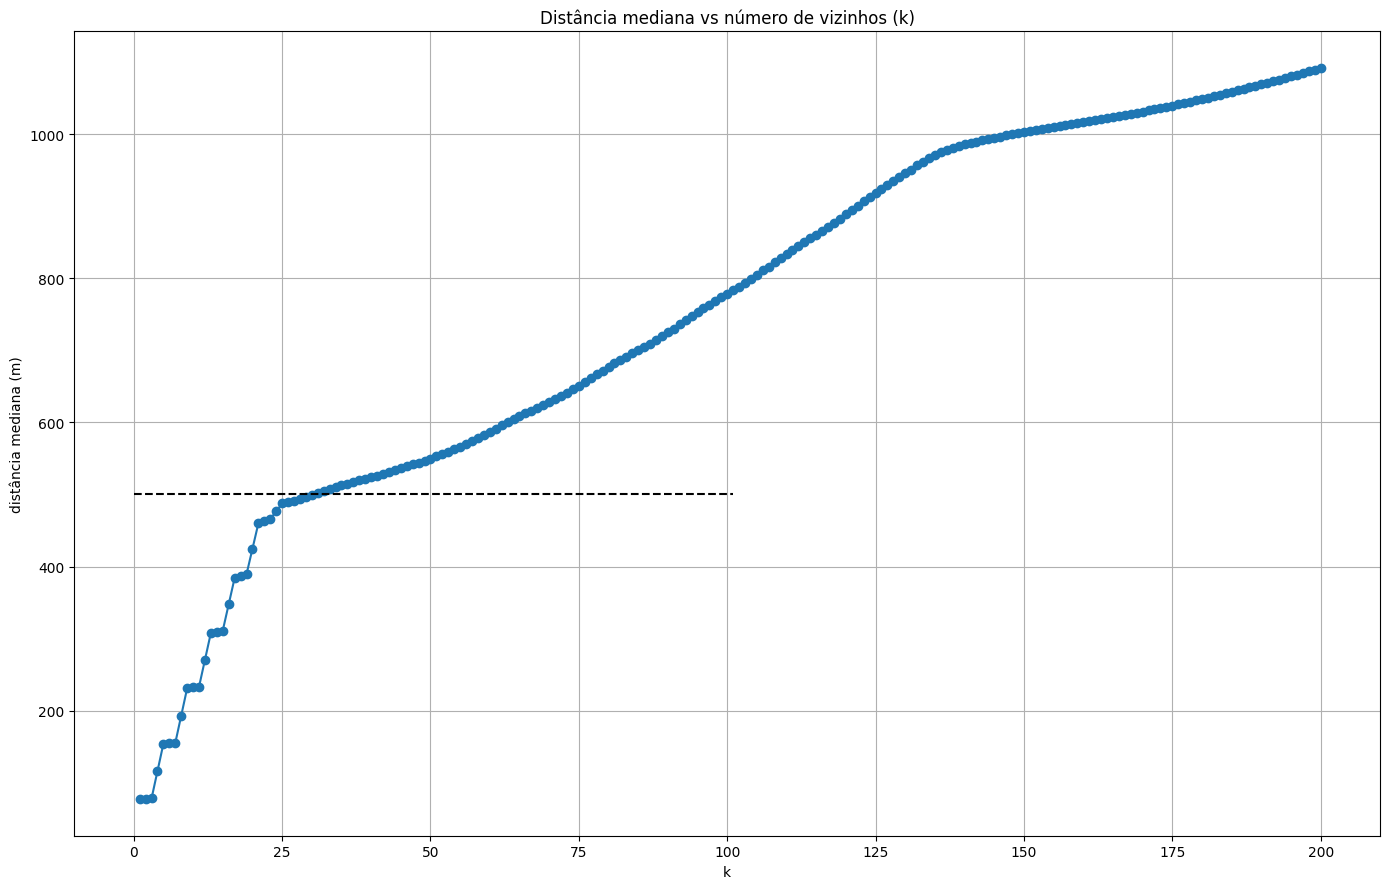

In [18]:
# Intervalo de k que queremos analisar
ks = np.arange(1, 201)  # 1 até 100
d_meds = []

for k in ks:
    # distâncias medianas aos k vizinhos mais próximos para cada ponto
    dist_k = vd.median_distance(coords, k_nearest=k)
    # uma única estatística global: mediana em todo o conjunto
    d_meds.append(np.median(dist_k))

d_meds = np.array(d_meds)

# Opcional: colocar em um DataFrame para inspeção numérica
df_knn = pd.DataFrame({"k": ks, "d_med_m": d_meds})
print(df_knn.head())
print(df_knn.tail())

import matplotlib.pyplot as plt
# assumindo que seu DataFrame se chama df
fig, ax = plt.subplots(figsize=(14,9))

ax.plot(df_knn["k"], df_knn["d_med_m"], marker="o", linestyle="-")
ax.set_xlabel("k")
ax.set_ylabel("distância mediana (m)")
ax.set_title("Distância mediana vs número de vizinhos (k)")
ax.hlines(y=500,xmin=0,xmax=101, linestyles='--', colors='black')
ax.grid(True)

plt.tight_layout()
plt.show()


In [19]:
# Espaçamento nominal entre linhas de voo (m)
line_spacing = 500.0

# df_knn já contém as colunas "k" e "d_med_m"

# 1) Variação absoluta da distância mediana entre k e k-1
df_knn["delta_d"] = df_knn["d_med_m"].diff()  # Na linha k=1 fica NaN

# 2) Variação relativa (taxa de crescimento)
df_knn["rel_delta"] = df_knn["delta_d"] / df_knn["d_med_m"].shift(1)

# 3) Diferença em relação aos 500 m (e valor absoluto)
df_knn["diff_to_500"] = df_knn["d_med_m"] - line_spacing
df_knn["abs_diff_500"] = df_knn["diff_to_500"].abs()

# Opcional: razão em relação ao espaçamento teórico
df_knn["ratio_to_500"] = df_knn["d_med_m"] / line_spacing

In [20]:
df_knn

,k,d_med_m,delta_d,rel_delta,diff_to_500,abs_diff_500,ratio_to_500
0,1,77.006493,NaN,NaN,-422.993507,422.993507,0.154013
1,2,77.503205,0.496712,0.006450,-422.496795,422.496795,0.155006
2,3,78.000000,0.496795,0.006410,-422.000000,422.000000,0.156000
3,4,116.003247,38.003247,0.487221,-383.996753,383.996753,0.232006
4,5,154.029218,38.025971,0.327801,-345.970782,345.970782,0.308058
...,...,...,...,...,...,...,...
195,196,1082.993277,2.339771,0.002165,582.993277,582.993277,2.165987
196,197,1085.122113,2.128836,0.001966,585.122113,585.122113,2.170244
197,198,1087.565732,2.443619,0.002252,587.565732,587.565732,2.175131
198,199,1089.861000,2.295269,0.002110,589.861000,589.861000,2.179722


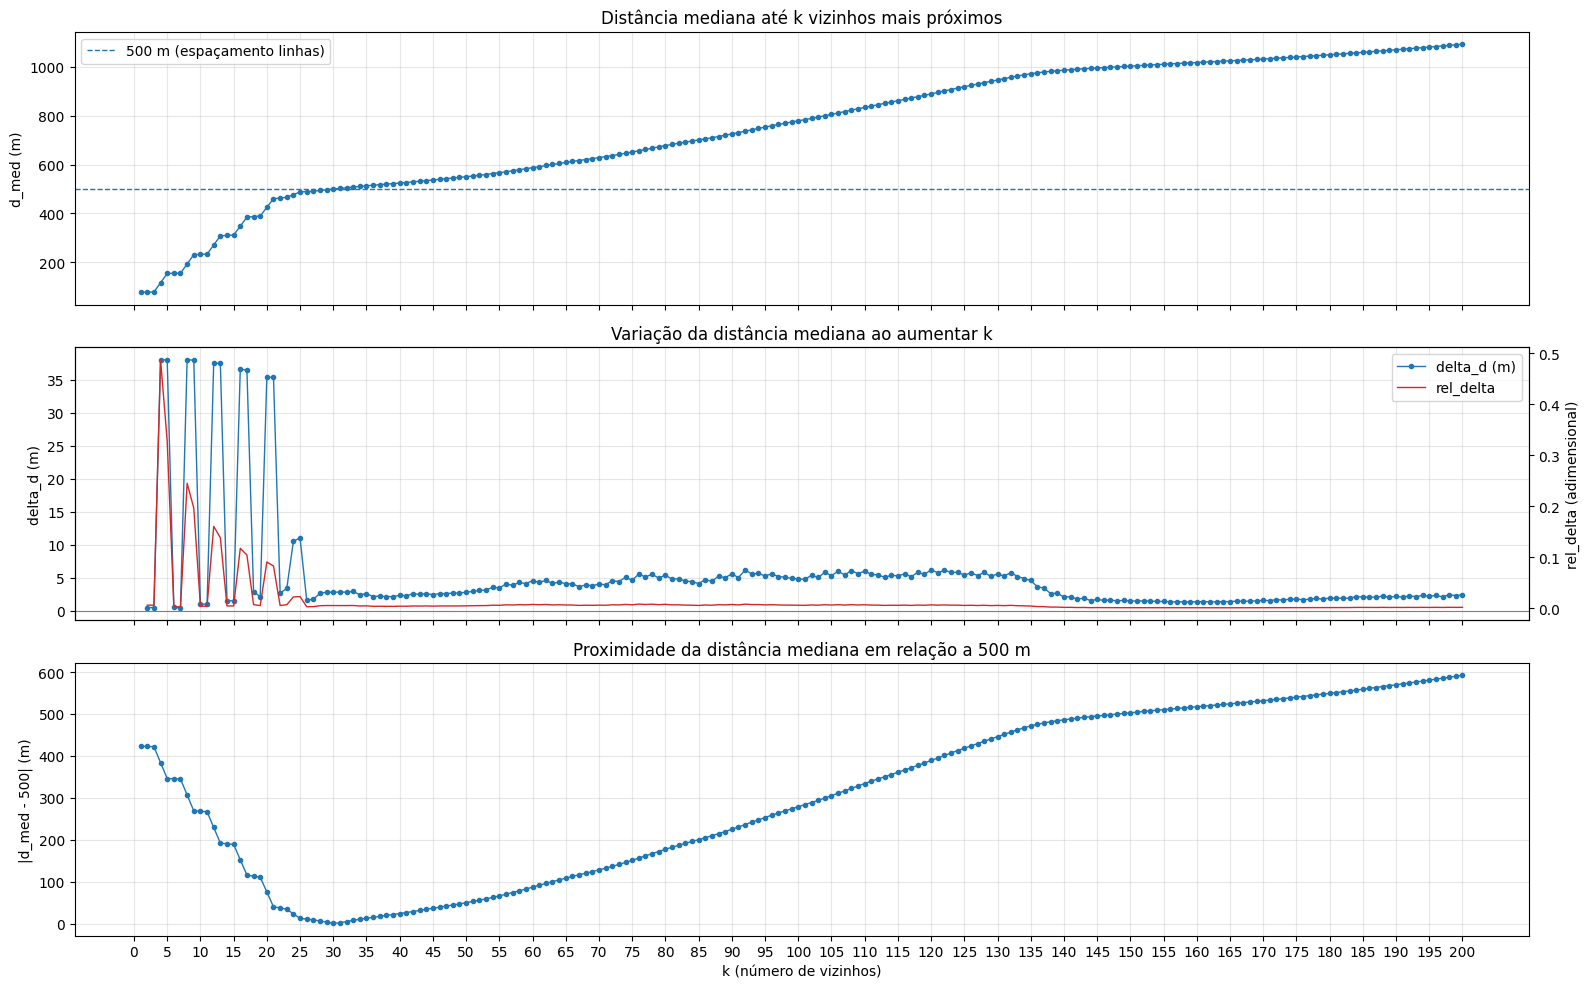

In [21]:
# Se quiser focar nos primeiros ks (por ex., até 100) para ficar mais legível:
k_max_plot = 500
df_plot = df_knn[df_knn["k"] <= k_max_plot].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# 1) d_med_m vs k
ax0 = axes[0]
ax0.plot(df_plot["k"], df_plot["d_med_m"], marker=".", linewidth=1)
ax0.axhline(500, linestyle="--", linewidth=1, label="500 m (espaçamento linhas)")
ax0.set_ylabel("d_med (m)")
ax0.set_title("Distância mediana até k vizinhos mais próximos")
ax0.grid(True, alpha=0.3)
ax0.legend(loc="upper left")


# 2) delta_d vs k + rel_delta no eixo secundário
ax1 = axes[1]
ax1.plot(df_plot["k"], df_plot["delta_d"], marker=".", linewidth=1, label="delta_d (m)")
ax1.axhline(0, color="gray", linewidth=0.8)
ax1.set_ylabel("delta_d (m)")
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(df_plot["k"], df_plot["rel_delta"], color="tab:red", linewidth=1, label="rel_delta")
ax1b.set_ylabel("rel_delta (adimensional)")

# Construir uma legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Variação da distância mediana ao aumentar k")

# 3) abs_diff_500 vs k (pode usar escala log)
ax2 = axes[2]
ax2.plot(df_plot["k"], df_plot["abs_diff_500"], marker=".", linewidth=1)
ax2.set_ylabel("|d_med - 500| (m)")
ax2.set_xlabel("k (número de vizinhos)")
ax2.set_title("Proximidade da distância mediana em relação a 500 m")
ax2.grid(True, alpha=0.3)
ax1.set_xticks(np.arange(0, 201, 5))

# opcional: escalar em log se ficar muito comprimido
# ax2.set_yscale("log")

plt.tight_layout()
plt.show()


In [22]:
# Variável usada na decimação (pode ser qualquer coluna contínua sem NaN)
var = "uth_razao"  # troque se preferir outra variável
values = df_folha_lito[var].values

N_orig = values.size
print("N original:", N_orig)

# --------------------------------------------------------
# Loop sobre todos os k do df_knn
# --------------------------------------------------------
n_out_list = []

for _, row in df_knn.iterrows():
    spacing_k = row["d_med_m"]  # espaçamento em metros para este k
    reducer = vd.BlockReduce(reduction='median', spacing=spacing_k)
    coords_red, vals_red = reducer.filter((x, y), values)
    n_out_list.append(vals_red.size)

df_knn["n_out"] = n_out_list
df_knn["red_ratio"] = df_knn["n_out"] / N_orig  # fração de pontos que sobrevivem


N original: 79993


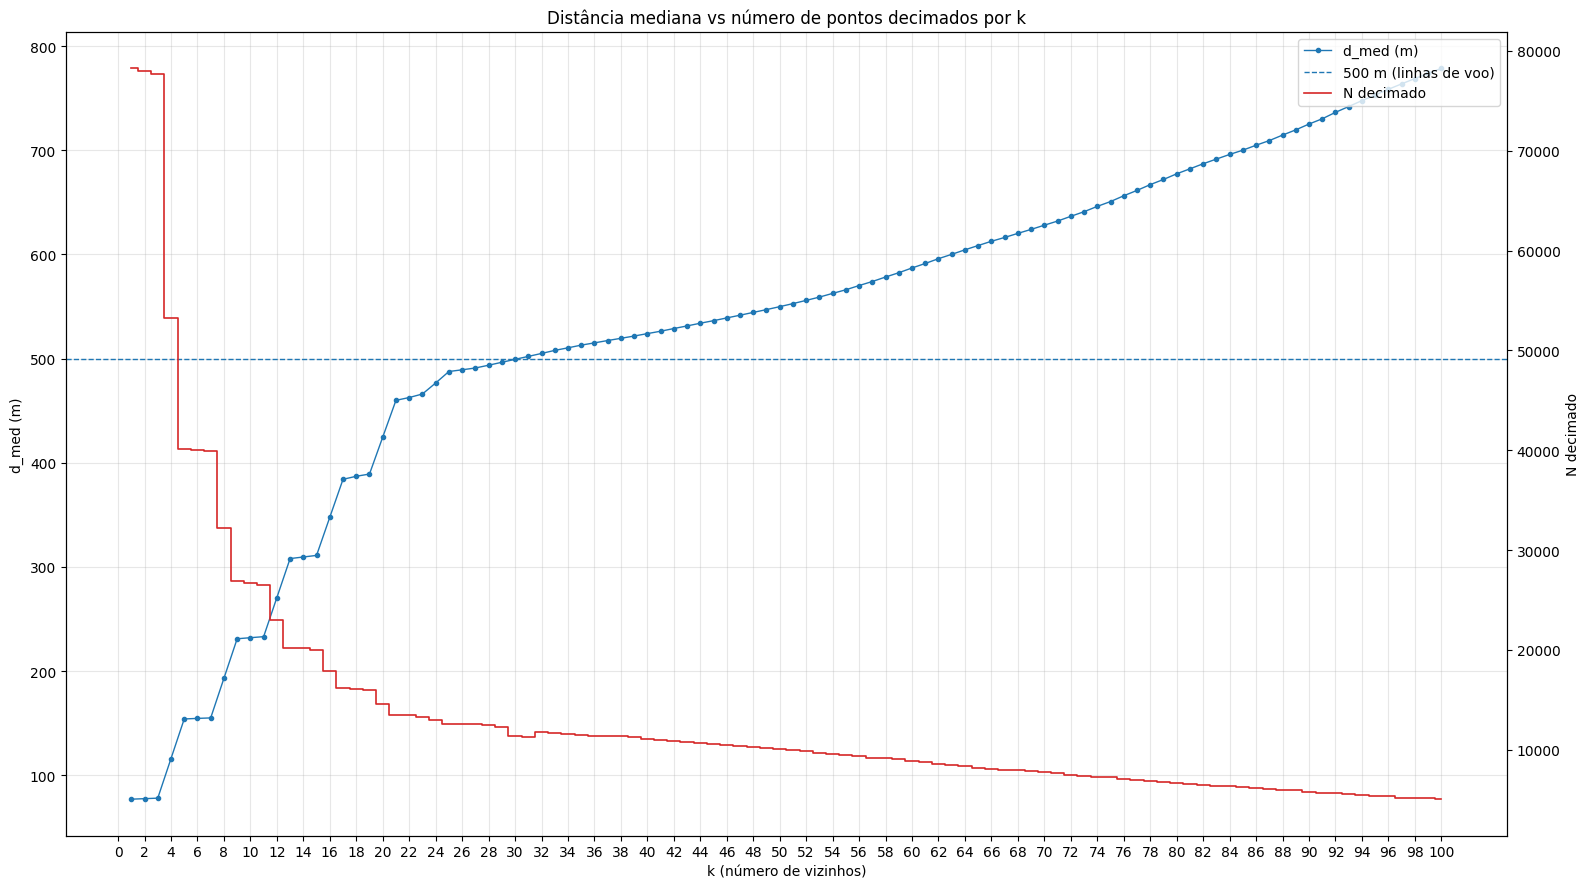

In [23]:
# Faixa de k para visualização
k_max_plot = 100
df_plot = df_knn[df_knn["k"] <= k_max_plot].copy()

fig, ax1 = plt.subplots(figsize=(16, 9))

# Eixo 1: d_med_m
ax1.plot(df_plot["k"], df_plot["d_med_m"], marker=".", linewidth=1,
         label="d_med (m)")
ax1.axhline(500, linestyle="--", linewidth=1, label="500 m (linhas de voo)")
ax1.set_xlabel("k (número de vizinhos)")
ax1.set_ylabel("d_med (m)")
ax1.grid(True, alpha=0.3)
k_min = df_plot["k"].min()
k_max = df_plot["k"].max()
ax1.set_xticks(np.arange(0, 101, 2))

# Eixo 2 (lado direito): n_out
ax2 = ax1.twinx()
ax2.step(df_plot["k"], df_plot["n_out"], where="mid",
         label="N decimado", linewidth=1.2, color="tab:red")
ax2.set_ylabel("N decimado")


# Legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Distância mediana vs número de pontos decimados por k")
plt.tight_layout()
plt.show()


In [25]:
df_folha_lito['fparam'] = df_folha_lito.uth_razao * df_folha_lito.kperc_np

In [29]:
var = "uth_razao"
values = df_folha_lito[var].values

N_orig = values.size
print("N original:", N_orig)

df_knn_k = df_knn.set_index("k")

# Fixar escala de cor
vmin, vmax = np.nanmin(values), np.nanmax(values)

# Slider de k
slider_k = widgets.IntSlider(
    value=30,
    min=1,
    max=100,
    step=1,
    description="k",
    continuous_update=True,
)

# Botão para ligar/desligar center_coordinates
toggle_center = widgets.ToggleButton(
    value=False,
    description="center_coordinates",
    tooltip="Usar centro dos blocos como coordenadas",
    icon="crosshairs"  # opcional
)

out_plot = widgets.Output()

def update(k, center):
    with out_plot:
        out_plot.clear_output(wait=True)

        spacing = df_knn_k.loc[k, "d_med_m"]

        # center_coordinates controlado pelo botão
        reducer = vd.BlockReduce(reduction="median", spacing=spacing, center_coordinates=center)
        (coords_red, values_red) = reducer.filter((x, y), values)
        x_red, y_red = coords_red

        print(
            f"k={k}, spacing≈{spacing:.1f} m, "
            f"N decimado={values_red.size}, "
            f"center_coordinates={center}"
        )

        fig, ax = plt.subplots(figsize=(19, 12))
        # pontos originais
        ax.scatter(x, y, s=1, alpha=0.2, label="original")
        # pontos decimados
        sc = ax.scatter(
            x_red, y_red,
            s=5,
            c=values_red,
            vmin=vmin, vmax=vmax,
            edgecolor="k",
            linewidth=0.2,
            label=(
                f"decimado (k={k}, spacing≈{spacing:.0f} m, "
                f"center={center})"
            ),
        )

        cbar = plt.colorbar(sc, ax=ax, label=var)
        folha_id =  'SB21_ZA_II1'

        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_title(
            f"Pontos decimados por BlockReduce ({var}) "
            f"para a área da folha {folha_id}"
        )
        ax.axis("scaled")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

        plt.tight_layout()
        plt.show()

# ligar widgets à função update
ui = widgets.HBox([slider_k, toggle_center])
out_plot.clear_output()
widgets.interactive_output(update, {"k": slider_k, "center": toggle_center})

display(ui, out_plot)


N original: 79993


Output()

In [6]:
df_folha_lito['f_param'].min()

NameError: name 'df_folha_lito' is not defined

In [31]:
coordinates = coords
cols_geof = [ "mdt", "ctcor_np", "kperc_np", "eu_np", "eth_np", "thk_razao", "uk_razao", "uth_razao",'f_param']

data = df_folha_lito[cols_geof +['x','y']]

In [32]:
data

,mdt,ctcor_np,kperc_np,eu_np,eth_np,thk_razao,uk_razao,uth_razao,f_param,x,y
0,169.96,501.281,0.450000,0.117585,5.925,12.979,0.182,0.014,0.006300,555419.0,9334276.0
1,168.97,687.889,0.593000,0.246000,7.700,13.872,0.672,0.048,0.028464,555408.0,9333810.0
2,248.55,543.309,0.240000,0.523000,6.681,29.064,2.266,0.078,0.018720,555407.0,9333114.0
3,231.33,538.212,0.161000,0.486000,7.161,41.201,2.817,0.068,0.010948,555408.0,9332881.0
4,176.71,522.825,0.303000,0.031000,7.356,25.852,0.000,0.000,0.000000,555416.0,9332327.0
...,...,...,...,...,...,...,...,...,...,...,...
79988,246.28,548.030,0.163000,0.282000,10.665,56.682,1.754,0.031,0.005053,610429.0,9287342.0
79989,207.65,651.813,0.505000,0.554000,10.569,21.298,1.264,0.059,0.029795,610427.0,9287007.0
79990,220.58,881.702,0.084000,0.919000,17.175,231.756,13.140,0.057,0.004788,610434.0,9285729.0
79991,229.11,776.626,0.036245,0.878000,16.017,0.000,0.000,0.057,0.002066,610434.0,9285389.0


In [33]:
df_folha_lito

,ctcor_np,kperc_np,eu_np,eth_np,thk_razao,uth_razao,uk_razao,x,y,mdt,...,folha_id,folha_codigo,folha_escala,folha_epsg,lito100k_id_unidade,lito100k_sigla,lito100k_nome,lito100k_legenda,f_param,fparam
0,501.281,0.450000,0.117585,5.925,12.979,0.014,0.182,555419.0,9334276.0,169.96,...,25267,SB21_ZA_II,100k,32721,1362,PP3cc,Complexo Cuiú-Cuiú,Gnaisse tonalítico a monzogranítico com migmat...,0.006300,0.006300
1,687.889,0.593000,0.246000,7.700,13.872,0.048,0.672,555408.0,9333810.0,168.97,...,25267,SB21_ZA_II,100k,32721,1362,PP3cc,Complexo Cuiú-Cuiú,Gnaisse tonalítico a monzogranítico com migmat...,0.028464,0.028464
2,543.309,0.240000,0.523000,6.681,29.064,0.078,2.266,555407.0,9333114.0,248.55,...,25267,SB21_ZA_II,100k,32721,1362,PP3cc,Complexo Cuiú-Cuiú,Gnaisse tonalítico a monzogranítico com migmat...,0.018720,0.018720
3,538.212,0.161000,0.486000,7.161,41.201,0.068,2.817,555408.0,9332881.0,231.33,...,25267,SB21_ZA_II,100k,32721,1362,PP3cc,Complexo Cuiú-Cuiú,Gnaisse tonalítico a monzogranítico com migmat...,0.010948,0.010948
4,522.825,0.303000,0.031000,7.356,25.852,0.000,0.000,555416.0,9332327.0,176.71,...,25267,SB21_ZA_II,100k,32721,1362,PP3cc,Complexo Cuiú-Cuiú,Gnaisse tonalítico a monzogranítico com migmat...,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79988,548.030,0.163000,0.282000,10.665,56.682,0.031,1.754,610429.0,9287342.0,246.28,...,25267,SB21_ZA_II,100k,32721,1362,PP3cc,Complexo Cuiú-Cuiú,Gnaisse tonalítico a monzogranítico com migmat...,0.005053,0.005053
79989,651.813,0.505000,0.554000,10.569,21.298,0.059,1.264,610427.0,9287007.0,207.65,...,25267,SB21_ZA_II,100k,32721,1362,PP3cc,Complexo Cuiú-Cuiú,Gnaisse tonalítico a monzogranítico com migmat...,0.029795,0.029795
79990,881.702,0.084000,0.919000,17.175,231.756,0.057,13.140,610434.0,9285729.0,220.58,...,25267,SB21_ZA_II,100k,32721,1316,PP3_gamma_cz,Suíte Creporizão,"Monzogranito e granodiorito, localmente porfir...",0.004788,0.004788
79991,776.626,0.036245,0.878000,16.017,0.000,0.057,0.000,610434.0,9285389.0,229.11,...,25267,SB21_ZA_II,100k,32721,1316,PP3_gamma_cz,Suíte Creporizão,"Monzogranito e granodiorito, localmente porfir...",0.002066,0.002066


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import verde as vd
import ipywidgets as widgets
from IPython.display import display

# -------------------------------------------------------
# Assumindo que df_folha_lito e df_knn já estão carregados
# -------------------------------------------------------
variaveis_disponiveis = [
    "mdt", "uth_razao", "ctcor_np", "eu_np", "eth_np",
    "kperc_np", "uk_razao", "thk_razao", "fparam"
]
interpoladores_disponiveis = ["Spline", "Cubic", "Linear"]
validadores_disponiveis = ["Train/Test Split", "KFold", "BlockKFold"]

df_knn_k = df_knn.set_index("k")

# Widgets
dropdown_var = widgets.Dropdown(
    options=variaveis_disponiveis, value="uth_razao", description="Variável:"
)
dropdown_method = widgets.Dropdown(
    options=interpoladores_disponiveis, value="Spline", description="Interpolador:"
)
dropdown_val = widgets.Dropdown(
    options=validadores_disponiveis, value="Train/Test Split", description="Validação:"
)

int_slider_kfold = widgets.IntSlider(
    min=2, max=10, step=1, value=5, description="n_splits"
)
float_slider_test = widgets.FloatSlider(
    min=0.1, max=0.9, step=0.1, value=0.3, description="test_size"
)
float_slider_block = widgets.FloatSlider(
    min=100, max=5000, step=5, value=1000, description="Block spacing"
)

slider_k = widgets.IntSlider(
    min=df_knn_k.index.min(),
    max=df_knn_k.index.max(),
    step=1,
    value=30,
    description="k (esp.)"
)

out_val = widgets.Output()

# -------------------------------------------------------
# Função para construir dinamicamente uma vd.Chain
# -------------------------------------------------------
def build_chain(method, spacing):
    reducer = vd.BlockReduce(
        reduction="median",
        spacing=spacing,
        center_coordinates=False,
    )

    if method == "Spline":
        interpolator = vd.Spline()
    elif method == "Cubic":
        interpolator = vd.Cubic()
    elif method == "Linear":
        interpolator = vd.Linear()
    else:
        raise ValueError("Interpolador inválido.")

    chain = vd.Chain(
        [
            ("reduce", reducer),
            #("trend", vd.Trend(degree=1)),
            ("interp", interpolator),
        ]
    )
    return chain


# -------------------------------------------------------
# Gerador de splits para as 3 estratégias de validação
# -------------------------------------------------------
def make_splits(val_type, X_full, y_full, n_splits, test_size, block_spacing):
    """
    Gera SEMPRE pares (train_idx, test_idx), agnóstico ao método de validação.
    """
    n_samples = X_full.shape[0]
    indices = np.arange(n_samples)

    if val_type == "Train/Test Split":
        train_idx, test_idx = train_test_split(
            indices, test_size=test_size
        )
        yield train_idx, test_idx

    elif val_type == "KFold":
        kf = KFold(n_splits=n_splits, shuffle=True)
        for train_idx, test_idx in kf.split(indices):
            yield train_idx, test_idx

    elif val_type == "BlockKFold":
        bkf = vd.BlockKFold(
            spacing=block_spacing,
            n_splits=n_splits,
            shuffle=True,
            random_state=42,
            balance=False,
        )
        # aqui o BlockKFold já usa X_full e y_full,
        # mas mesmo assim só devolvemos os índices
        for train_idx, test_idx in bkf.split(X_full, y_full):
            yield train_idx, test_idx

    else:
        raise ValueError("Tipo de validação inválido.")


# -------------------------------------------------------
# Função principal de avaliação usando vd.Chain
# -------------------------------------------------------
def run_val(var, method, val_type, n_splits, test_size, block_spacing, k):
    with out_val:
        out_val.clear_output(wait=True)

        spacing = df_knn_k.loc[k, "d_med_m"]

        X_full = np.column_stack(
            [df_folha_lito["x"].values, df_folha_lito["y"].values]
        )
        y_full = df_folha_lito[var].values

        chain = build_chain(method, spacing)

        y_test_all, y_pred_all = [], []
        X_test_points = []

        # Loop único para todos os esquemas de validação
        for X_train, X_test, y_train, y_test in make_splits(
            val_type, X_full, y_full, n_splits, test_size, block_spacing
        ):
            chain.fit((X_train[:, 0], X_train[:, 1]), y_train)
            y_pred = chain.predict((X_test[:, 0], X_test[:, 1]))

            X_test_points.append(X_test)
            y_test_all.append(y_test)
            y_pred_all.append(y_pred)

        # Empilha todos os folds / splits
        X_test_plot = np.vstack(X_test_points)
        y_test = np.concatenate(y_test_all)
        y_pred = np.concatenate(y_pred_all)
        residuals = y_test - y_pred

        # ---------------------------------------------------
        # Métricas
        # (mantido: "RMSE" usando mean_squared_error sem sqrt,
        # para não alterar resultados numéricos já usados)
        # ---------------------------------------------------
        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)

        print(f"R²:   {r2:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE:  {mae:.4f}")

        # ---------------------------------------------------
        # Plot 1: Observado vs Predito + histograma de resíduos
        # ---------------------------------------------------
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))

        y_min, y_max = np.min(y_test), np.max(y_test)

        axes[0].scatter(y_test, y_pred, s=5, alpha=0.5)
        axes[0].plot([y_min, y_max], [y_min, y_max], "k--")
        axes[0].set_title("Predito vs Observado")
        axes[0].set_xlabel("Valor observado")
        axes[0].set_ylabel("Valor predito")
        axes[0].grid(True)

        axes[1].hist(residuals, bins="auto", color="gray", edgecolor="black")
        axes[1].set_title("Distribuição dos resíduos")
        axes[1].set_xlabel("Erro (resíduo)")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------
        # Plot 2: Resíduos espaciais
        # ---------------------------------------------------
        scale = vd.maxabs(residuals)

        fig2, ax2 = plt.subplots(figsize=(8, 8))
        sc = ax2.scatter(
            X_test_plot[:, 0],
            X_test_plot[:, 1],
            c=residuals,
            cmap="RdBu",
            s=10,
            vmin=-scale,
            vmax=scale,
            edgecolor="k",
            linewidth=0.3,
        )
        plt.colorbar(sc, ax=ax2, label="Resíduo (observado - predito)")
        ax2.set_title(f"Resíduos no espaço (k={k}, spacing≈{spacing:.1f} m)")
        ax2.set_aspect("equal")
        ax2.grid(True)
        plt.show()


# -------------------------------------------------------
# Interface interativa
# -------------------------------------------------------
def wrapper(var, method, val_type, n_splits, test_size, block_spacing, k):
    run_val(var, method, val_type, n_splits, test_size, block_spacing, k)


controls = widgets.interactive_output(
    wrapper,
    {
        "var": dropdown_var,
        "method": dropdown_method,
        "val_type": dropdown_val,
        "n_splits": int_slider_kfold,
        "test_size": float_slider_test,
        "block_spacing": float_slider_block,
        "k": slider_k,
    },
)

ui = widgets.VBox(
    [
        widgets.HBox([dropdown_var, dropdown_method, dropdown_val]),
        widgets.HBox([int_slider_kfold, float_slider_test, float_slider_block, slider_k]),
    ]
)

display(ui, controls, out_val)

Output()

Output()

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import verde as vd
import ipywidgets as widgets
from IPython.display import display

# -------------------------------------------------------
# Assumindo que df_folha_lito e df_knn já estão carregados
# -------------------------------------------------------
variaveis_disponiveis = ["mdt", "uth_razao", "ctcor_np", "eu_np", "eth_np", "kperc_np", "uk_razao", "thk_razao", "fparam"]
interpoladores_disponiveis = ["Spline", "Cubic", "Linear"]
validadores_disponiveis = ["Train/Test Split", "KFold", "BlockKFold"]

df_knn_k = df_knn.set_index("k")

# Widgets
dropdown_var = widgets.Dropdown(options=variaveis_disponiveis, value="uth_razao", description="Variável:")
dropdown_method = widgets.Dropdown(options=interpoladores_disponiveis, value="Spline", description="Interpolador:")
dropdown_val = widgets.Dropdown(options=validadores_disponiveis, value="Train/Test Split", description="Validação:")

int_slider_kfold = widgets.IntSlider(min=2, max=10, step=1, value=5, description="n_splits")
float_slider_test = widgets.FloatSlider(min=0.1, max=0.9, step=0.1, value=0.3, description="test_size")
float_slider_block = widgets.FloatSlider(min=100, max=5000, step=5, value=1000, description="Block spacing")

slider_k = widgets.IntSlider(
    min=df_knn_k.index.min(),
    max=df_knn_k.index.max(),
    step=1,
    value=30,
    description="k (esp.)"
)

out_val = widgets.Output()

# -------------------------------------------------------
# Função para construir dinamicamente uma vd.Chain
# -------------------------------------------------------
def build_chain(method, spacing):
    reducer = vd.BlockReduce(
        reduction="median",
        spacing=spacing,
        center_coordinates=False,
    )

    if method == "Spline":
        interpolator = vd.Spline()
    elif method == "Cubic":
        interpolator = vd.Cubic()
    elif method == "Linear":
        interpolator = vd.Linear()
    else:
        raise ValueError("Interpolador inválido.")

    chain = vd.Chain([
        ("reduce", reducer),
        ("trend", vd.Trend(degree=1)),
        ("interp", interpolator),
    ])

    return chain


# -------------------------------------------------------
# Função principal de avaliação usando vd.Chain
# -------------------------------------------------------
def run_val(var, method, val_type, n_splits, test_size, block_spacing, k):
    with out_val:
        out_val.clear_output(wait=True)

        spacing = df_knn_k.loc[k, "d_med_m"]

        X_full = np.column_stack([df_folha_lito["x"].values, df_folha_lito["y"].values])
        y_full = df_folha_lito[var].values

        chain = build_chain(method, spacing)

        X_test_plot = None
        residuals_plot = None

        # ---------------------------------------------------
        # Estratégias de validação
        # ---------------------------------------------------
        if val_type == "Train/Test Split":
            X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=test_size)

            chain.fit((X_train[:,0], X_train[:,1]), y_train)
            y_pred = chain.predict((X_test[:,0], X_test[:,1]))

            X_test_plot = X_test
            residuals_plot = y_test - y_pred

        elif val_type == "KFold":
            kf = KFold(n_splits=n_splits, shuffle=True)

            y_test_all, y_pred_all = [], []
            X_test_points = []

            for train_idx, test_idx in kf.split(X_full):
                X_train, X_test = X_full[train_idx], X_full[test_idx]
                y_train, y_test = y_full[train_idx], y_full[test_idx]

                chain.fit((X_train[:,0], X_train[:,1]), y_train)
                y_pred = chain.predict((X_test[:,0], X_test[:,1]))

                X_test_points.append(X_test)
                y_test_all.append(y_test)
                y_pred_all.append(y_pred)

            X_test_plot = np.vstack(X_test_points)
            y_test = np.concatenate(y_test_all)
            y_pred = np.concatenate(y_pred_all)
            residuals_plot = y_test - y_pred

        elif val_type == "BlockKFold":
            bkf = vd.BlockKFold(
                spacing=block_spacing,
                n_splits=n_splits,
                shuffle=True,
                random_state=42,
                balance=False,
            )

            y_test_all, y_pred_all = [], []
            X_test_points = []

            for train_idx, test_idx in bkf.split(X_full, y_full):
                X_train, X_test = X_full[train_idx], X_full[test_idx]
                y_train, y_test = y_full[train_idx], y_full[test_idx]

                chain.fit((X_train[:,0], X_train[:,1]), y_train)
                y_pred = chain.predict((X_test[:,0], X_test[:,1]))

                X_test_points.append(X_test)
                y_test_all.append(y_test)
                y_pred_all.append(y_pred)

            X_test_plot = np.vstack(X_test_points)
            y_test = np.concatenate(y_test_all)
            y_pred = np.concatenate(y_pred_all)
            residuals_plot = y_test - y_pred

        # ---------------------------------------------------
        # Métricas
        # ---------------------------------------------------
        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)

        print(f"R²:   {r2:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE:  {mae:.4f}")

        # ---------------------------------------------------
        # Plot 1: Observado vs Predito
        # ---------------------------------------------------
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))

        axes[0].scatter(y_test, y_pred, s=5, alpha=0.5)
        axes[0].plot(
            [min(y_test), max(y_test)],
            [min(y_test), max(y_test)],
            "k--"
        )
        axes[0].set_title("Predito vs Observado")
        axes[0].set_xlabel("Valor observado")
        axes[0].set_ylabel("Valor predito")
        axes[0].grid(True)

        residuals = y_test - y_pred
        axes[1].hist(residuals, bins='auto', color='gray', edgecolor='black')
        axes[1].set_title("Distribuição dos resíduos")
        axes[1].set_xlabel("Erro (resíduo)")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------
        # Plot 2: Resíduos espaciais
        # ---------------------------------------------------
        if X_test_plot is not None:
            scale = vd.maxabs(residuals_plot)

            fig2, ax2 = plt.subplots(figsize=(8,8))
            sc = ax2.scatter(
                X_test_plot[:,0],
                X_test_plot[:,1],
                c=residuals_plot,
                cmap="RdBu_r",
                s=10,
                vmin=-scale,
                vmax=scale,
                edgecolor="k",
                linewidth=0.3
            )
            plt.colorbar(sc, ax=ax2, label="Resíduo (observado - predito)")
            ax2.set_title(f"Resíduos no espaço (k={k}, spacing≈{spacing:.1f} m)")
            ax2.set_aspect("equal")
            ax2.grid(True)
            plt.show()



# -------------------------------------------------------
# Interface interativa
# -------------------------------------------------------
def wrapper(var, method, val_type, n_splits, test_size, block_spacing, k):
    run_val(var, method, val_type, n_splits, test_size, block_spacing, k)

controls = widgets.interactive_output(
    wrapper,
    {
        "var": dropdown_var,
        "method": dropdown_method,
        "val_type": dropdown_val,
        "n_splits": int_slider_kfold,
        "test_size": float_slider_test,
        "block_spacing": float_slider_block,
        "k": slider_k,
    }
)

ui = widgets.VBox([
    widgets.HBox([dropdown_var, dropdown_method, dropdown_val]),
    widgets.HBox([int_slider_kfold, float_slider_test, float_slider_block, slider_k])
])

display(ui, controls, out_val)


Output()

Output()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import verde as vd
import ipywidgets as widgets
from IPython.display import display

# -------------------------------------------------------
# Assumindo que df_folha_lito e df_knn já estão carregados
# -------------------------------------------------------
variaveis_disponiveis = [
    "mdt", "uth_razao", "ctcor_np", "eu_np", "eth_np",
    "kperc_np", "uk_razao", "thk_razao", "fparam"
]
interpoladores_disponiveis = ["Spline", "Cubic", "Linear"]
validadores_disponiveis = ["Train/Test Split", "KFold", "BlockKFold"]

df_knn_k = df_knn.set_index("k")

# Widgets
dropdown_var = widgets.Dropdown(
    options=variaveis_disponiveis, value="uth_razao", description="Variável:"
)
dropdown_method = widgets.Dropdown(
    options=interpoladores_disponiveis, value="Spline", description="Interpolador:"
)
dropdown_val = widgets.Dropdown(
    options=validadores_disponiveis, value="Train/Test Split", description="Validação:"
)

int_slider_kfold = widgets.IntSlider(
    min=2, max=10, step=1, value=5, description="n_splits"
)
float_slider_test = widgets.FloatSlider(
    min=0.1, max=0.9, step=0.1, value=0.3, description="test_size"
)
float_slider_block = widgets.FloatSlider(
    min=100, max=5000, step=5, value=1000, description="Block spacing"
)

slider_k = widgets.IntSlider(
    min=df_knn_k.index.min(),
    max=df_knn_k.index.max(),
    step=1,
    value=30,
    description="k (esp.)"
)

out_val = widgets.Output()

# -------------------------------------------------------
# Função para construir dinamicamente uma vd.Chain
# -------------------------------------------------------
def build_chain(method, spacing):
    reducer = vd.BlockReduce(
        reduction="median",
        spacing=spacing,
        center_coordinates=False,
    )

    if method == "Spline":
        interpolator = vd.Spline()
    elif method == "Cubic":
        interpolator = vd.Cubic()
    elif method == "Linear":
        interpolator = vd.Linear()
    else:
        raise ValueError("Interpolador inválido.")

    chain = vd.Chain(
        [
            ("reduce", reducer),
            # ("trend", vd.Trend(degree=1)),
            ("interp", interpolator),
        ]
    )
    return chain


# -------------------------------------------------------
# Gerador de splits: sempre devolve índices
# -------------------------------------------------------
def make_splits(val_type, X_full, y_full, n_splits, test_size, block_spacing):
    """
    Gera SEMPRE pares (train_idx, test_idx), agnóstico ao método de validação.
    """
    n_samples = X_full.shape[0]
    indices = np.arange(n_samples)

    if val_type == "Train/Test Split":
        train_idx, test_idx = train_test_split(
            indices, test_size=test_size
        )
        yield train_idx, test_idx

    elif val_type == "KFold":
        kf = KFold(n_splits=n_splits, shuffle=True)
        for train_idx, test_idx in kf.split(indices):
            yield train_idx, test_idx

    elif val_type == "BlockKFold":
        bkf = vd.BlockKFold(
            spacing=block_spacing,
            n_splits=n_splits,
            shuffle=True,
            random_state=42,
            balance=False,
        )
        # BlockKFold usa as coordenadas X_full e (opcionalmente) y_full,
        # mas aqui retornamos apenas os índices
        for train_idx, test_idx in bkf.split(X_full, y_full):
            yield train_idx, test_idx

    else:
        raise ValueError("Tipo de validação inválido.")


# -------------------------------------------------------
# Função principal de avaliação usando vd.Chain
# -------------------------------------------------------
def run_val(var, method, val_type, n_splits, test_size, block_spacing, k):
    with out_val:
        out_val.clear_output(wait=True)

        # espaçamento vindo do estudo de k-vizinhos
        spacing = df_knn_k.loc[k, "d_med_m"]

        # matriz de features (x, y) e variável alvo
        X_full = np.column_stack(
            [df_folha_lito["x"].values, df_folha_lito["y"].values]
        )
        y_full = df_folha_lito[var].values

        chain = build_chain(
            method,
            spacing
        )

        # Acumuladores para métricas globais
        y_test_all, y_pred_all = [], []

        # Arrays "globais" de resíduos por ponto (agnósticos ao validador)
        residuals_full = np.full_like(y_full, np.nan, dtype=float)
        is_test_full = np.zeros_like(y_full, dtype=bool)

        # Loop único para todos os esquemas de validação
        for train_idx, test_idx in make_splits(
            val_type, X_full, y_full, n_splits, test_size, block_spacing
        ):
            X_train, X_test = X_full[train_idx], X_full[test_idx]
            y_train, y_test = y_full[train_idx], y_full[test_idx]

            # Ajuste do Chain
            chain.fit((X_train[:, 0], X_train[:, 1]), y_train)
            y_pred = chain.predict((X_test[:, 0], X_test[:, 1]))

            # Resíduos deste fold
            resid_fold = y_test - y_pred

            # Acumula para métricas
            y_test_all.append(y_test)
            y_pred_all.append(y_pred)

            # Preenche arrays globais
            residuals_full[test_idx] = resid_fold
            is_test_full[test_idx] = True

        # Empilha todos os folds / splits
        y_test = np.concatenate(y_test_all)
        y_pred = np.concatenate(y_pred_all)
        residuals = y_test - y_pred

        # ---------------------------------------------------
        # Métricas
        # (mantido: "RMSE" usando mean_squared_error sem sqrt)
        # ---------------------------------------------------
        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)

        print(f"Variável: {var}")
        print(f"Validação: {val_type}")
        print(f"Interpolador: {method}")
        print(f"k (esp.): {k}  -> spacing≈{spacing:.1f} m")
        print(f"R²:   {r2:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE:  {mae:.4f}")

        # ---------------------------------------------------
        # Plot 1: Observado vs Predito + histograma de resíduos
        # ---------------------------------------------------
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))

        y_min, y_max = np.min(y_test), np.max(y_test)

        axes[0].scatter(y_test, y_pred, s=5, alpha=0.5)
        axes[0].plot([y_min, y_max], [y_min, y_max], "k--")
        axes[0].set_title("Predito vs Observado")
        axes[0].set_xlabel("Valor observado")
        axes[0].set_ylabel("Valor predito")
        axes[0].grid(True)

        axes[1].hist(residuals, bins="auto", color="gray", edgecolor="black")
        axes[1].set_title("Distribuição dos resíduos (todos os folds)")
        axes[1].set_xlabel("Erro (resíduo)")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------
        # Plot 2: Resíduos espaciais (agnóstico ao validador)
        # ---------------------------------------------------
        coords_plot = X_full[is_test_full]
        residuals_plot = residuals_full[is_test_full]

        scale = vd.maxabs(residuals_plot)

        fig2, ax2 = plt.subplots(figsize=(8, 8))
        sc = ax2.scatter(
            coords_plot[:, 0],
            coords_plot[:, 1],
            c=residuals_plot,
            cmap="RdBu_r",
            s=10,
            vmin=-scale,
            vmax=scale,
            edgecolor="k",
            linewidth=0.3,
        )
        plt.colorbar(sc, ax=ax2, label="Resíduo (observado - predito)")
        ax2.set_title(f"Resíduos no espaço (k={k}, spacing≈{spacing:.1f} m)")
        ax2.set_aspect("equal")
        ax2.grid(True)
        plt.show()


# -------------------------------------------------------
# Interface interativa
# -------------------------------------------------------
def wrapper(var, method, val_type, n_splits, test_size, block_spacing, k):
    run_val(var, method, val_type, n_splits, test_size, block_spacing, k)


controls = widgets.interactive_output(
    wrapper,
    {
        "var": dropdown_var,
        "method": dropdown_method,
        "val_type": dropdown_val,
        "n_splits": int_slider_kfold,
        "test_size": float_slider_test,
        "block_spacing": float_slider_block,
        "k": slider_k,
    },
)

ui = widgets.VBox(
    [
        widgets.HBox([dropdown_var, dropdown_method, dropdown_val]),
        widgets.HBox([int_slider_kfold, float_slider_test, float_slider_block, slider_k]),
    ]
)

display(ui, controls, out_val)


NameError: name 'df_knn' is not defined

## Griding with Splines

In [ ]:
region_total = [data.x.min(), data.x.max(), 
                data.y.min(), data.y.max()]
region_total
df_folha_lito['fparam'] = df_folha_lito['uth_razao'] * df_folha_lito['kperc_np']

In [8]:
# -------------------------------------------------------
# 0) Variáveis disponíveis para interpolação
# -------------------------------------------------------
variaveis_disponiveis = ["mdt", "uth_razao", "ctcor_np", "eu_np", "eth_np", "kperc_np", 'uk_razao', 'thk_razao', 'fparam']  # adicione as que desejar

dropdown_var = widgets.Dropdown(
    options=variaveis_disponiveis,
    value="uth_razao",
    description="Variável:",
)

# -------------------------------------------------------
# 1) Outros widgets
# -------------------------------------------------------
slider_k = widgets.IntSlider(
    value=100,
    min=1,
    max=100,
    step=1,
    description="k",
    continuous_update=True,
)

toggle_center = widgets.ToggleButton(
    value=False,
    description="center_coordinates",
    tooltip="Usar centro dos blocos como coordenadas",
    icon="crosshairs",
)

dropdown_method = widgets.Dropdown(
    options=["Spline", "Cubic", "Linear"],
    value="Spline",
    description="Método:",
)

out_plot = widgets.Output()

# -------------------------------------------------------
# 2) Cache de interpolação (agora também inclui var)
# -------------------------------------------------------
interpol_cache = {}

# -------------------------------------------------------
# 3) Função de atualização
# -------------------------------------------------------
def update(var, k, center, method):
    with out_plot:
        out_plot.clear_output(wait=True)

        values = df_folha_lito[var].values
        spacing = df_knn_k.loc[k, "d_med_m"]
        key = (var, k, center, method)

        if key in interpol_cache:
            grid, coords_red, values_red, grid_spacing = interpol_cache[key]
        else:
            reducer = vd.BlockReduce(
                reduction="median",
                spacing=spacing,
                center_coordinates=center,
            )
            coords_red, values_red = reducer.filter((x, y), values)
            x_red, y_red = coords_red

            if method == "Spline":
                interpolator = vd.Spline(damping=1e-10)
            elif method == "Cubic":
                interpolator = vd.Cubic()
            elif method == "Linear":
                interpolator = vd.Linear()
            else:
                raise ValueError(f"Método inválido: {method}")

            interpolator.fit((x_red, y_red), values_red)
            grid_spacing = spacing / 5.0
            grid = interpolator.grid(
                region=region_total,
                spacing=grid_spacing,
                data_names=[var],
            )

            interpol_cache[key] = (grid, coords_red, values_red, grid_spacing)

        x_red, y_red = coords_red

        print(
            f"var={var}, k={k}, spacing_decim≈{spacing:.1f} m, "
            f"center_coordinates={center}, method={method}, "
            f"N decimado={values_red.size}, "
            f"grid_spacing≈{grid_spacing:.1f} m"
        )

        fig, ax = plt.subplots(figsize=(16, 12))
        pc = ax.pcolormesh(grid.easting, grid.northing, grid[var], shading="auto")
        plt.colorbar(pc, ax=ax, label=var)

        ax.scatter(
            x_red, y_red,
            s=5,
            facecolor="none",
            edgecolor="k",
            linewidth=0.3,
            label="amostras decimadas",
        )

        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.set_title(
            f"{method} sobre dados decimados ({var})\n"
            f"folha SB21_ZA_II1, k={k}, spacing≈{spacing:.0f} m"
        )
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

# -------------------------------------------------------
# 4) Interface final
# -------------------------------------------------------
ui = widgets.HBox([dropdown_var, slider_k, toggle_center, dropdown_method])
out_plot.clear_output()
widgets.interactive_output(update, {
    "var": dropdown_var,
    "k": slider_k,
    "center": toggle_center,
    "method": dropdown_method,
})

display(ui, out_plot)


Output()

In [ ]:
## %matplotlib inline
import pyproj
import verde as vd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import warnings

# Opcional: suprimir FutureWarning específicos do Verde/Sklearn
warnings.filterwarnings(
    "ignore",
    message="The default scoring will change from R² to negative root mean squared error",
    category=FutureWarning,
)
warnings.filterwarnings(
    "ignore",
    message="The mindist parameter of verde.Spline is no longer required",
    category=FutureWarning,
)

# -------------------------------------------
# 0) Dados já carregados
# -------------------------------------------
var = "eu"

x = df_folha_lito['x'].values
y = df_folha_lito['y'].values
values = df_folha_lito[var].values

df_knn_k = df_knn.set_index("k")

vmin, vmax = np.nanmin(values), np.nanmax(values)

print("N original:", values.size)
print("Região XY:", region_xy)

# Widgets
slider_k = widgets.IntSlider(
    value=30,
    min=1,
    max=100,
    step=1,
    description="k",
    continuous_update=True,
)

toggle_center = widgets.ToggleButton(
    value=False,
    description="center_coordinates",
    tooltip="Usar centro dos blocos como coordenadas",
    icon="crosshairs",
)

out = widgets.Output()

def update(k, center):
    with out:
        out.clear_output(wait=True)
        spacing = df_knn_k.loc[k, "d_med_m"]

        # 1) Decimação
        reducer = vd.BlockReduce(
            reduction="mean",
            spacing=spacing,
            center_coordinates=center,
        )
        (coords_red, values_red) = reducer.filter((x, y), values)
        x_red, y_red = coords_red

        # 2) Fit do Spline
        spline = vd.Spline(damping=1e-10)
        spline.fit((x_red, y_red), values_red)

        pred_train = spline.predict((x_red, y_red))
        resid = values_red - pred_train
        rmse_train = np.sqrt(np.mean(resid**2))

        # 3) Cross-validation espacial com scoring explícito
        cv_spacing = spacing * 4.0
        cv = vd.BlockKFold(
            spacing=cv_spacing,
            n_splits=5,
            shuffle=True,
            random_state=0,
        )

        # (a) R² – scoring especificado explicitamente
        scores_r2 = vd.cross_val_score(
            vd.Spline(damping=1e-10),
            (x_red, y_red),
            values_red,
            cv=cv,
            scoring="r2",  # evita o aviso sobre mudança de padrão
        )
        r2_mean = np.mean(scores_r2)
        r2_std = np.std(scores_r2)

        # (b) RMSE – usar scoring de RMSE negativo nativo do Verde (>=1.8)
        scores_neg_rmse = vd.cross_val_score(
            vd.Spline(damping=1e-10),
            (x_red, y_red),
            values_red,
            cv=cv,
            scoring="neg_root_mean_squared_error",
        )
        rmse_scores = -scores_neg_rmse
        rmse_mean = np.mean(rmse_scores)
        rmse_std = np.std(rmse_scores)

        # 4) Grid
        grid_spacing = spacing / 5.0
        grid = spline.grid(
            region=region_xy,
            spacing=grid_spacing,
            data_names=[var],
        )

        # 5) Plots
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # (a) mapa interp.
        ax = axes[0]
        pc = ax.pcolormesh(
            grid.easting,
            grid.northing,
            grid[var],
            shading="auto",
            vmin=vmin,
            vmax=vmax,
        )
        fig.colorbar(pc, ax=ax, label=var)

        ax.scatter(
            x_red,
            y_red,
            s=8,
            facecolor="none",
            edgecolor="k",
            linewidth=0.3,
            label="amostras decimadas",
        )

        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.set_title(
            f"Spline ({var}) – folha {folha_id}\n"
            f"k={k}, spacing≈{spacing:.0f} m, center_coordinates={center}"
        )
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

        # (b) histograma de resíduos
        ax2 = axes[1]
        ax2.hist(resid, bins='auto', alpha=0.7)
        ax2.axvline(0, linestyle="--", linewidth=1)
        ax2.set_title("Resíduos no conjunto decimado")
        ax2.set_xlabel("resíduo (obs − pred)")
        ax2.set_ylabel("contagem")

        plt.tight_layout()
        plt.show()

        # 6) Resumo numérico
        print(f"N original:  {values.size}")
        print(f"N decimado:  {values_red.size}")
        print(f"spacing (k={k}): {spacing:.1f} m | center_coordinates={center}")
        print('')
        print(
            f"Treino (decimado): "
            f"mean(res)={np.mean(resid):.4g}, "
            f"std(res)={np.std(resid):.4g}, "
            f"RMSE_treino={rmse_train:.4g}"
        )
        print(
            f"CV BlockKFold: spacing_cv={cv_spacing:.1f} m, "
            f"n_splits={len(scores_r2)}"
        )
        print(
            f"  R²  : mean={r2_mean:.4f}, std={r2_std:.4f}, "
            f"scores={np.array2string(scores_r2, precision=3)}"
        )
        print(
            f"  RMSE: mean={rmse_mean:.4f}, std={rmse_std:.4f}, "
            f"scores={np.array2string(rmse_scores, precision=3)}"
        )

ui = widgets.HBox([slider_k, toggle_center])
out.clear_output()
widgets.interactive_output(
    update,
    {"k": slider_k, "center": toggle_center},
)

display(ui, out)

In [ ]:
def make_chain(spacing, center):
    return vd.Chain(
        [
            (
                "reduce",
                vd.BlockReduce(
                    reduction="mean",
                    spacing=spacing,
                    center_coordinates=center,
                ),
            ),
            ("spline", vd.Spline(damping=1e-10)),
        ]
    )

import pyproj
import verde as vd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import warnings

# Opcional: suprimir FutureWarning específicos do Verde/Sklearn
warnings.filterwarnings(
    "ignore",
    message="The default scoring will change from R² to negative root mean squared error",
    category=FutureWarning,
)
warnings.filterwarnings(
    "ignore",
    message="The mindist parameter of verde.Spline is no longer required",
    category=FutureWarning,
)

# -------------------------------------------
# 0) Dados já carregados_valid
# -------------------------------------------
var = "eu"

x = df_folha_lito['x'].values
y = df_folha_lito['y'].values
values = df_folha_lito[var].values

df_knn_k = df_knn.set_index("k")

vmin, vmax = np.nanmin(values), np.nanmax(values)

print("N original:", values.size)
print("Região XY:", region_total)

# Widgets
slider_k = widgets.IntSlider(
    value=200,
    min=1,
    max=200,
    step=1,
    description="k",
    continuous_update=True,
)

toggle_center = widgets.ToggleButton(
    value=False,
    description="center_coordinates",
    tooltip="Usar centro dos blocos como coordenadas",
    icon="crosshairs",
)

out = widgets.Output()
def update(k, center):
    with out:
        out.clear_output(wait=True)
        spacing = df_knn_k.loc[k, "d_med_m"]
        coords = (x, y)

        # 1) Ajuste da cadeia (BlockReduce + Spline)
        chain = make_chain(spacing, center)
        chain.fit(coords, values)

        # Recuperar dados decimados para diagnóstico
        reducer = chain.named_steps["reduce"]
        (coords_red, values_red) = reducer.filter(coords, values)
        x_red, y_red = coords_red

        # Previsão e resíduos no conjunto decimado
        pred_train = chain.named_steps["spline"].predict(coords_red)
        resid = values_red - pred_train
        rmse_train = np.sqrt(np.mean(resid**2))

        # 2) Cross-validation espacial da cadeia completa
        cv_spacing = spacing * 4.0
        cv = vd.BlockKFold(
            spacing=cv_spacing,
            n_splits=5,
            shuffle=True,
            random_state=0,
        )

        # (a) R²
        scores_r2 = vd.cross_val_score(
            make_chain(spacing, center),
            coords,
            values,
            cv=cv,
            scoring="r2",
        )
        r2_mean = np.mean(scores_r2)
        r2_std = np.std(scores_r2)

        # (b) RMSE (neg_root_mean_squared_error → multiplicar por -1)
        scores_neg_rmse = vd.cross_val_score(
            make_chain(spacing, center),
            coords,
            values,# Layout atualizado com novo dropdown
ui = widgets.HBox([slider_k, toggle_center, dropdown_method])
out_plot.clear_output()

# Associar widgets à função update
widgets.interactive_output(update, {
    "k": slider_k,
    "center": toggle_center,
    "method": dropdown_method,
})

display(ui, out_plot)

            cv=cv,
            scoring="neg_root_mean_squared_error",
        )
        rmse_scores = -scores_neg_rmse
        rmse_mean = np.mean(rmse_scores)
        rmse_std = np.std(rmse_scores)

        # 3) Grid com a cadeia ajustada
        grid_spacing = spacing / 5.0
        grid = chain.grid(
            region=region_total,
            spacing=grid_spacing,
            data_names=[var],
        )

        # 4) Plots
        fig, axes = plt.subplots(1, 2, figsize=(24, 9))

        # (a) mapa interp.
        ax = axes[0]
        pc = ax.pcolormesh(
            grid.easting,
            grid.northing,
            grid[var],
            shading="auto",
            vmin=vmin,
            vmax=vmax,
        )
        fig.colorbar(pc, ax=ax, label=var)

        ax.scatter(
            x_red,
            y_red,
            s=8,
            facecolor="none",
            edgecolor="k",
            linewidth=0.3,
            label="amostras decimadas",
        )

        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.set_title(
            f"Spline ({var}) – folha {df_folha_lito.folha_codigo.unique()}\n"
            f"k={k}, spacing≈{spacing:.1f} m, center_coordinates={center}"
        )
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

        # (b) histograma de resíduos
        ax2 = axes[1]
        ax2.hist(resid, bins='auto', alpha=0.7)
        ax2.axvline(0, linestyle="--", linewidth=1)
        ax2.set_title("Resíduos no conjunto decimado")
        ax2.set_xlabel("resíduo (obs − pred)")
        ax2.set_ylabel("contagem")

        plt.tight_layout()
        plt.show()

        # 5) Resumo numérico
        print(f"N original:  {values.size}")
        print(f"N decimado:  {values_red.size}")
        print(f"spacing (k={k}): {spacing:.1f} m | center_coordinates={center}")
        print("")
        print(
            f"Treino (decimado): "
            f"mean(res)={np.mean(resid):.4g}, "
            f"std(res)={np.std(resid):.4g}, "
            f"RMSE_treino={rmse_train:.4g}"
        )
        print(
            f"CV BlockKFold (cadeia): spacing_cv={cv_spacing:.1f} m, "
            f"n_splits={len(scores_r2)}"
        )
        print(
            f"  R²  : mean={r2_mean:.4f}, std={r2_std:.4f}, "
            f"scores={np.array2string(scores_r2, precision=3)}"
        )
        print(
            f"  RMSE: mean={rmse_mean:.4f}, std={rmse_std:.4f}, "
            f"scores={np.array2string(rmse_scores, precision=3)}"
        )


ui = widgets.HBox([slider_k, toggle_center])
out.clear_output()
widgets.interactive_output(
    update,
    {"k": slider_k, "center": toggle_center},
)

display(ui, out)
